In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
df = pd.read_csv('D:\Github\ML projects\Telco-churn-classification\data\processed_data.csv')
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,0,0,1,0


In [43]:
df.describe(include='all')

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,...,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.504756,0.162147,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,2281.916928,0.265370,...,0.290217,0.216669,0.384353,0.216669,0.387903,0.209144,0.240664,0.216101,0.335794,0.228880
std,0.500013,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,2265.270398,0.441561,...,0.453895,0.412004,0.486477,0.412004,0.487307,0.406726,0.427517,0.411613,0.472301,0.420141
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,402.225000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1397.475000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,3786.600000,1.000000,...,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7043 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   int64  
 11  Mult

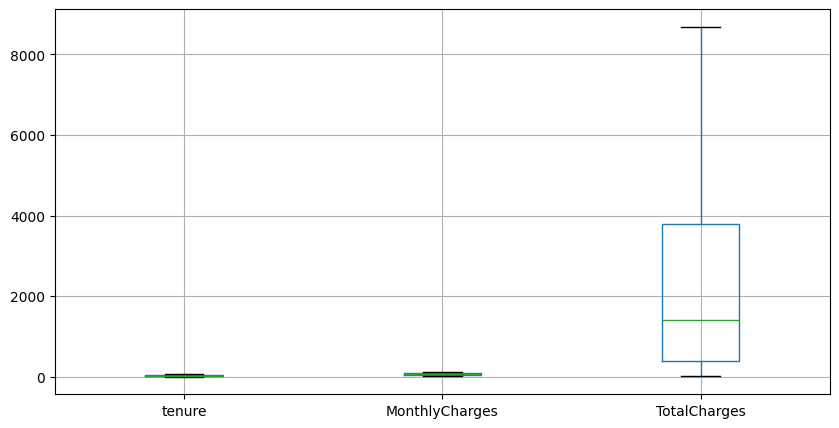

In [45]:
outlier_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']
boxplot = df[outlier_columns].boxplot(figsize=(10, 5))
plt.show()


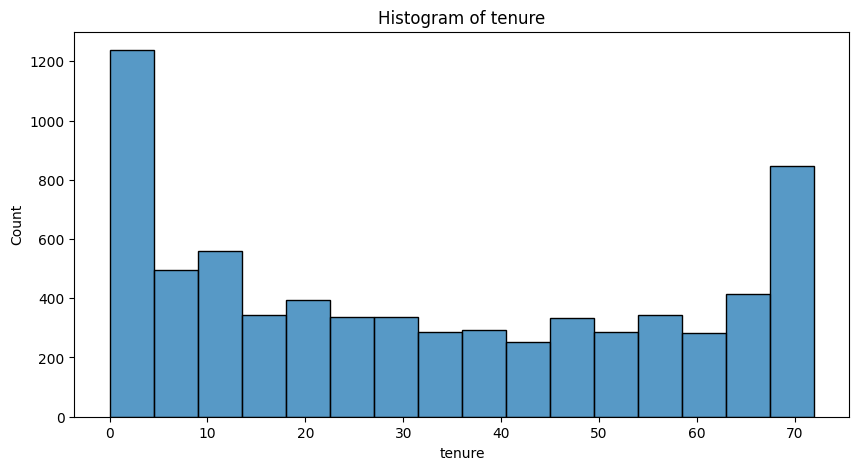

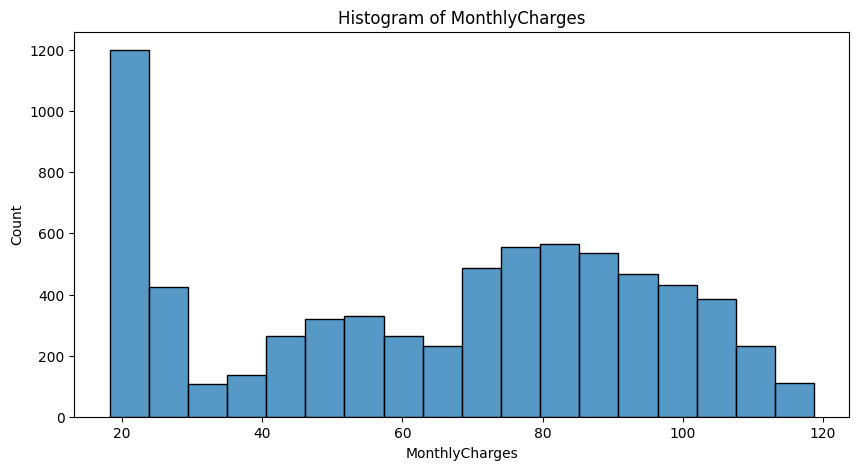

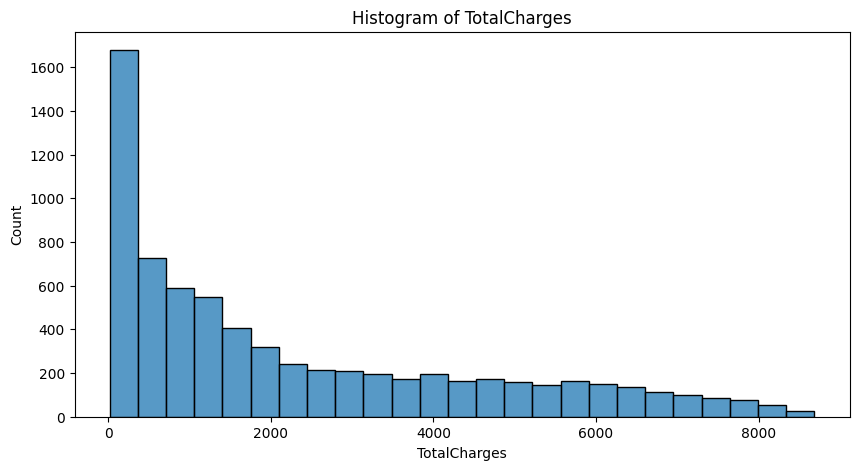

In [46]:
for col in outlier_columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(x=df[col])
    plt.title(f'Histogram of {col}')
    plt.show()

In [47]:

from scipy import stats
z_scores = np.abs(stats.zscore(df[outlier_columns]))
outliers = df[(z_scores > 3).any(axis=1)]
print(outliers)


Empty DataFrame
Columns: [gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, PaperlessBilling, MonthlyCharges, TotalCharges, Churn, MultipleLines_No phone service, MultipleLines_Yes, InternetService_Fiber optic, InternetService_No, OnlineSecurity_No internet service, OnlineSecurity_Yes, OnlineBackup_No internet service, OnlineBackup_Yes, DeviceProtection_No internet service, DeviceProtection_Yes, TechSupport_No internet service, TechSupport_Yes, StreamingTV_No internet service, StreamingTV_Yes, StreamingMovies_No internet service, StreamingMovies_Yes, Contract_One year, Contract_Two year, PaymentMethod_Credit card (automatic), PaymentMethod_Electronic check, PaymentMethod_Mailed check]
Index: []

[0 rows x 31 columns]


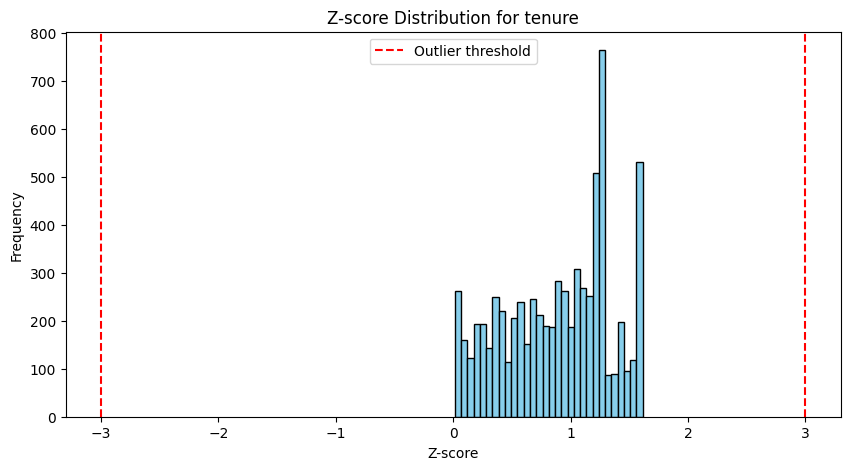

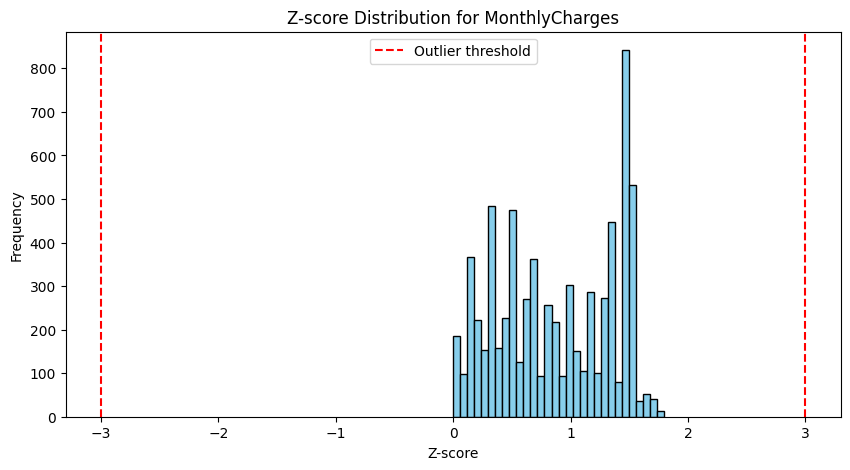

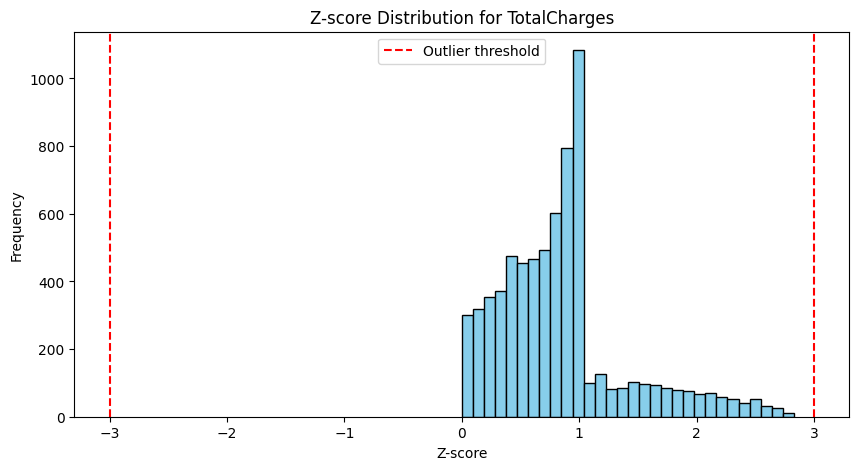

In [48]:
for i, col in enumerate(outlier_columns):
    plt.figure(figsize=(10, 5))
    plt.hist(z_scores[:, i], bins=30, color='skyblue', edgecolor='black')
    plt.axvline(3, color='red', linestyle='--', label='Outlier threshold')
    plt.axvline(-3, color='red', linestyle='--')
    plt.xlabel("Z-score")
    plt.ylabel("Frequency")
    plt.title(f"Z-score Distribution for {col}")
    plt.legend()
    plt.show()


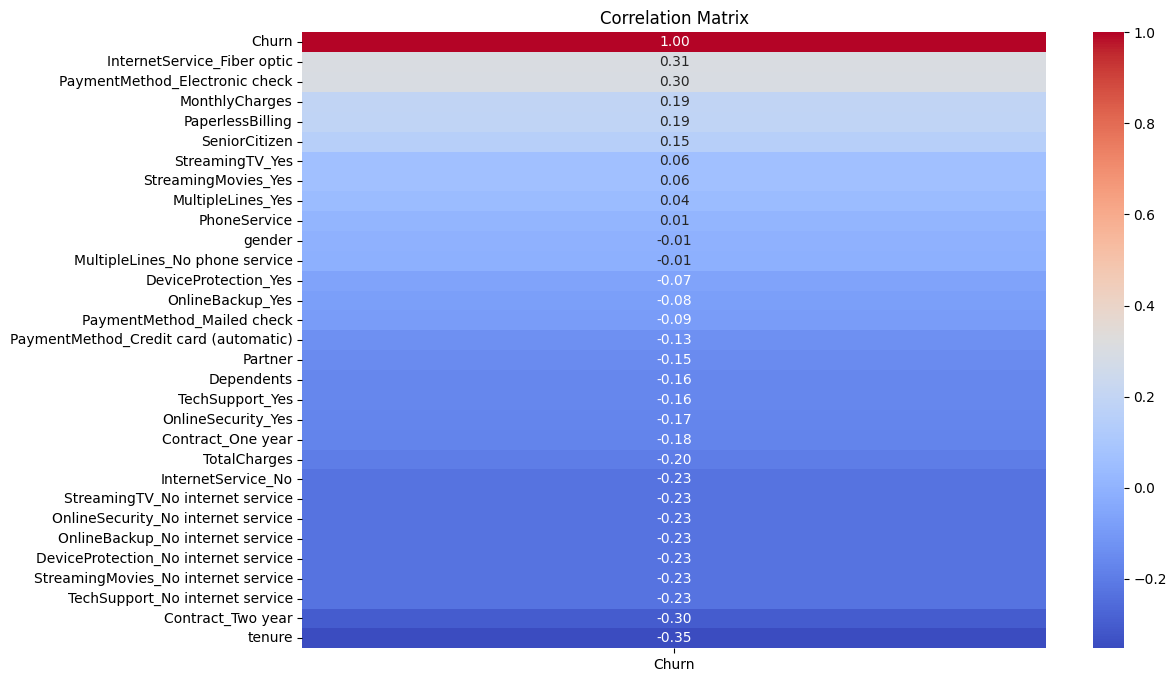

In [49]:
#correlation matrix
correlation_matrix = df.corr(numeric_only=True)
#focus on churn 
churn_correlation = correlation_matrix['Churn'].sort_values(ascending=False)
plt.figure(figsize=(12, 8))
sns.heatmap(churn_correlation.to_frame(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [50]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'Churn', 'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [51]:
#multicollinearity check using Variance Inflation Factor (VIF)
# from statsmodels.stats.outliers_influence import variance_inflation_factor
# from statsmodels.tools.tools import add_constant
# df.drop(["Churn"], axis=1, inplace=True, errors='ignore')
# df.drop(["TotalCharges", "MonthlyCharges", "StreamingMovies_Yes"], axis=1, inplace=True)
# X = df

# X = add_constant(X)

# vif = pd.DataFrame()
# vif["Variable"] = X.columns
# vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
# vif = vif[vif["VIF"] > 10]
# print(vif)

In [52]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Step 1: Drop target and some known redundant features
df.drop(["Churn"], axis=1, inplace=True, errors='ignore')
df.drop(["TotalCharges", "MonthlyCharges", "StreamingMovies_Yes"], axis=1, inplace=True)

X = df
X = add_constant(X)

# Step 2: Calculate VIF
vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif = vif[vif["VIF"] > 10]   # keep only high-VIF features
print(vif)

# Step 3: Extract high-VIF feature names
high_vif_features = vif["Variable"].tolist()

# Step 4: Scale the high-VIF features
X_high_vif = X[high_vif_features]
X_scaled = StandardScaler().fit_transform(X_high_vif)

# Step 5: Apply PCA (retain 95% variance)
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

# Step 6: Create PCA DataFrame
pca_cols = [f"PC{i+1}" for i in range(X_pca.shape[1])]
X_pca_df = pd.DataFrame(X_pca, columns=pca_cols, index=X.index)

# Step 7: Build final dataset
final_df = pd.concat([X.drop(columns=high_vif_features), X_pca_df], axis=1)

# Step 8: Inspect
print("Original shape:", X.shape)
print("Final shape:", final_df.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative explained variance:", np.cumsum(pca.explained_variance_ratio_))


                                Variable  VIF
6                           PhoneService  inf
8         MultipleLines_No phone service  inf
11                    InternetService_No  inf
12    OnlineSecurity_No internet service  inf
14      OnlineBackup_No internet service  inf
16  DeviceProtection_No internet service  inf
18       TechSupport_No internet service  inf
20       StreamingTV_No internet service  inf
22   StreamingMovies_No internet service  inf
Original shape: (7043, 28)
Final shape: (7043, 21)
Explained variance ratio: [0.78685571 0.21314429]
Cumulative explained variance: [0.78685571 1.        ]


In [53]:
final_df.head()
final_df.shape
original_df = pd.read_csv(r"D:\Github\ML projects\Telco-churn-classification\data\processed_data.csv")
final_data = pd.concat([final_df, original_df["Churn"]], axis=1)

In [56]:
final_data.columns

Index(['const', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PaperlessBilling', 'MultipleLines_Yes', 'InternetService_Fiber optic',
       'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes',
       'TechSupport_Yes', 'StreamingTV_Yes', 'Contract_One year',
       'Contract_Two year', 'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'PC1',
       'PC2', 'Churn'],
      dtype='object')

In [55]:
final_data.to_csv("D:\\Github\\ML projects\\Telco-churn-classification\\data\\final_data.csv", index=False)